# 18.12 The TF-Agents Library

In [1]:
import tensorflow as tf

print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2023-09-30 09:42:47.561923: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2023-09-30 09:42:47.657498: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2023-09-30 09:42:47.657760: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

## TF-Agents Environments

In [2]:
from tf_agents.environments import suite_gym

env = suite_gym.load("Breakout-v4", render_kwargs={"render_mode": "rgb_array"})
env

A.L.E: Arcade Learning Environment (version 0.7.5+db37282)
[Powered by Stella]


In [3]:
env.gym

<TimeLimit<OrderEnforcing<AtariEnv<Breakout-v4>>>>

## Environment Specification

In [4]:
env.observation_spec()

BoundedArraySpec(shape=(210, 160, 3), dtype=dtype('uint8'), name='observation', minimum=0, maximum=255)

In [5]:
env.action_spec()

BoundedArraySpec(shape=(), dtype=dtype('int64'), name='action', minimum=0, maximum=3)

In [6]:
ts = env.reset()
ts.is_first()

True

In [7]:
ts = env.step(1)
print(ts.is_first())
print(ts.is_mid())

False
True


In [8]:
env.current_time_step()

TimeStep(
{'discount': array(1., dtype=float32),
 'observation': array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8),
 'reward': array(0., dtype=float32),
 'step_type': array(1, dtype=int32)})

In [9]:
env.observation_spec()

BoundedArraySpec(shape=(210, 160, 3), dtype=dtype('uint8'), name='observation', minimum=0, maximum=255)

In [10]:
env.action_spec()

BoundedArraySpec(shape=(), dtype=dtype('int64'), name='action', minimum=0, maximum=3)

In [11]:
env.time_step_spec()

TimeStep(
{'discount': BoundedArraySpec(shape=(), dtype=dtype('float32'), name='discount', minimum=0.0, maximum=1.0),
 'observation': BoundedArraySpec(shape=(210, 160, 3), dtype=dtype('uint8'), name='observation', minimum=0, maximum=255),
 'reward': ArraySpec(shape=(), dtype=dtype('float32'), name='reward'),
 'step_type': ArraySpec(shape=(), dtype=dtype('int32'), name='step_type')})

In [12]:
env.get_action_meanings()

['NOOP', 'FIRE', 'RIGHT', 'LEFT']

## Environment Wrappers and Atari Preprocessing

In [13]:
from tf_agents.environments.wrappers import ActionRepeat

env_repeating = ActionRepeat(env, times=4)
env_repeating

In [14]:
from gym.wrappers import TimeLimit

env_limited_repeating = suite_gym.load(
    "BreakoutNoFrameskip-v4",
    gym_env_wrappers=[lambda env: TimeLimit(env, max_episode_steps=10_000)],
    env_wrappers=[lambda env: ActionRepeat(env, 4)],
)
env_limited_repeating

In [15]:
from tf_agents.environments import suite_atari
from tf_agents.environments.atari_preprocessing import AtariPreprocessing
from tf_agents.environments.atari_wrappers import FrameStack4

environment_name = "BreakoutNoFrameskip-v4"
max_episode_steps = 27_000  # 108k

env = suite_atari.load(
    environment_name=environment_name,
    max_episode_steps=max_episode_steps,
    gym_env_wrappers=[AtariPreprocessing, FrameStack4],
)

In [16]:
from tf_agents.environments.tf_py_environment import TFPyEnvironment

tf_env = TFPyEnvironment(env)
tf_env

2023-09-30 09:42:48.419874: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2023-09-30 09:42:48.420134: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2023-09-30 09:42:48.420288: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

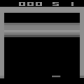

In [17]:
import PIL

data = tf_env.current_time_step().observation.numpy()[0]
img = PIL.Image.fromarray(data[:, :, :-1], mode="RGB")
img
# data.shape

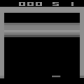

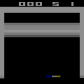

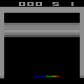

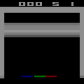

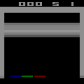

In [18]:
tf_env.reset()
for i_step in range(5):
    obs = tf_env.step(3).observation.numpy()[0]
    obs_last = obs[:, :, -1]
    obs_comb = obs[
        :, :, :-1
    ]  # + np.stack([obs_last, np.zeros_like(obs_last), obs_last], axis=-1)
    display(PIL.Image.fromarray(obs_comb, mode="RGB"))

## Creating the Deep Q-Network

In [19]:
from tf_agents.networks import q_network

preprocessing_layer = tf.keras.layers.Lambda(
    lambda obs: tf.cast(obs, tf.float32) / 255.0
)
conv_layer_params = [(32, (8, 8), 4), (64, (4, 4), 2), (64, (3, 3), 1)]
fc_layer_params = [512]

q_net = q_network.QNetwork(
    input_tensor_spec=tf_env.observation_spec(),
    action_spec=tf_env.action_spec(),
    preprocessing_layers=preprocessing_layer,
    conv_layer_params=conv_layer_params,
    fc_layer_params=fc_layer_params,
)

## Creating the DQN Agent

In [20]:
from tf_agents.agents.dqn.dqn_agent import DqnAgent

train_step = tf.Variable(0)
update_period = 4  # Train the model every four steps
optimizer = tf.keras.optimizers.RMSprop(
    learning_rate=2.5e-4, rho=0.95, momentum=0.0, epsilon=1e-5, centered=True
)
td_errors_loss_fn = tf.keras.losses.Huber(reduction=tf.keras.losses.Reduction.NONE)
epsilon_fn = tf.keras.optimizers.schedules.PolynomialDecay(
    initial_learning_rate=1.0,  # Initial epsilon
    decay_steps=250_000 // update_period,  # <=> 1,000,000 ALE frames
    end_learning_rate=0.01,  # Final epsilon
)

agent = DqnAgent(
    time_step_spec=tf_env.time_step_spec(),
    action_spec=tf_env.action_spec(),
    q_network=q_net,
    optimizer=optimizer,
    target_update_period=2000,  # <==> 32,000 ALE frames
    td_errors_loss_fn=td_errors_loss_fn,
    gamma=0.99,
    train_step_counter=train_step,
    epsilon_greedy=lambda: epsilon_fn(train_step),
)
agent.initialize()

2023-09-30 09:42:50.372681: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8800
2023-09-30 09:42:51.398946: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2023-09-30 09:42:51.399700: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2023-09-30 09:42:51.399722: W tensorflow/compiler/xla/stream_executor/gpu/asm_compiler.cc:109] Couldn't get ptxas version : FAILED_PRECONDITION: Couldn't get ptxas/nvlink version string: INTERNAL: Couldn't invoke ptxas --version
2023-09-30 09:42:51.400482: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2023-09-30 09:42:51.400537: W tensorflow/compiler/xla/stream_executor/gpu/redzone_allocator.cc:317] INTERNAL: Failed to launch ptxas
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This mes

## Creating the Replay Buffer and the Corresponding Observer

In [21]:
agent.collect_data_spec

Trajectory(
{'action': BoundedTensorSpec(shape=(), dtype=tf.int64, name='action', minimum=array(0), maximum=array(3)),
 'discount': BoundedTensorSpec(shape=(), dtype=tf.float32, name='discount', minimum=array(0., dtype=float32), maximum=array(1., dtype=float32)),
 'next_step_type': TensorSpec(shape=(), dtype=tf.int32, name='step_type'),
 'observation': BoundedTensorSpec(shape=(84, 84, 4), dtype=tf.uint8, name='observation', minimum=array(0, dtype=uint8), maximum=array(255, dtype=uint8)),
 'policy_info': (),
 'reward': TensorSpec(shape=(), dtype=tf.float32, name='reward'),
 'step_type': TensorSpec(shape=(), dtype=tf.int32, name='step_type')})

In [22]:
tf_env.batch_size

1

In [23]:
from tf_agents.replay_buffers import tf_uniform_replay_buffer

replay_buffer = tf_uniform_replay_buffer.TFUniformReplayBuffer(
    data_spec=agent.collect_data_spec,
    batch_size=tf_env.batch_size,
    max_length=100_000,
)

2023-09-30 09:42:51.678906: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 2822400000 exceeds 10% of free system memory.


In [24]:
replay_buffer_observer = replay_buffer.add_batch

In [25]:
class ShowProgress:
    def __init__(self, total: int) -> None:
        self.counter: int = 0
        self.total: int = total

    def __call__(self, trajectory) -> None:
        if not trajectory.is_boundary():
            self.counter += 1
        if self.counter % 100 == 0:
            print(f"\r {self.counter}/{self.total}", end="")

## Creating Training Metrics

In [26]:
from tf_agents.metrics import tf_metrics

train_metrics = [
    tf_metrics.NumberOfEpisodes(),
    tf_metrics.EnvironmentSteps(),
    tf_metrics.AverageReturnMetric(),
    tf_metrics.AverageEpisodeLengthMetric(),
]

In [27]:
train_metrics[0].result()

<tf.Tensor: shape=(), dtype=int64, numpy=0>

In [28]:
import logging
from tf_agents.eval.metric_utils import log_metrics

logging.getLogger().setLevel(logging.INFO)
log_metrics(train_metrics)

INFO:absl: 
		 NumberOfEpisodes = 0
		 EnvironmentSteps = 0
		 AverageReturn = 0.0
		 AverageEpisodeLength = 0.0


## Creating the Collect Driver

In [29]:
from tf_agents.drivers.dynamic_step_driver import DynamicStepDriver

collect_driver = DynamicStepDriver(
    env=tf_env,
    policy=agent.collect_policy,
    observers=[replay_buffer_observer] + train_metrics,
    num_steps=update_period,
)

In [30]:
from tf_agents.policies.random_tf_policy import RandomTFPolicy

initial_collect_policy = RandomTFPolicy(
    time_step_spec=tf_env.time_step_spec(),
    action_spec=tf_env.action_spec(),
)

init_driver = DynamicStepDriver(
    env=tf_env,
    policy=initial_collect_policy,
    observers=[replay_buffer_observer, ShowProgress(20_000)],
    num_steps=20_000,
)
final_time_step, final_policy_state = init_driver.run()
final_time_step

 20000/20000

TimeStep(
{'discount': <tf.Tensor: shape=(1,), dtype=float32, numpy=array([1.], dtype=float32)>,
 'observation': <tf.Tensor: shape=(1, 84, 84, 4), dtype=uint8, numpy=
array([[[[0, 0, 0, 0],
         [0, 0, 0, 0],
         [0, 0, 0, 0],
         ...,
         [0, 0, 0, 0],
         [0, 0, 0, 0],
         [0, 0, 0, 0]],

        [[0, 0, 0, 0],
         [0, 0, 0, 0],
         [0, 0, 0, 0],
         ...,
         [0, 0, 0, 0],
         [0, 0, 0, 0],
         [0, 0, 0, 0]],

        [[0, 0, 0, 0],
         [0, 0, 0, 0],
         [0, 0, 0, 0],
         ...,
         [0, 0, 0, 0],
         [0, 0, 0, 0],
         [0, 0, 0, 0]],

        ...,

        [[0, 0, 0, 0],
         [0, 0, 0, 0],
         [0, 0, 0, 0],
         ...,
         [0, 0, 0, 0],
         [0, 0, 0, 0],
         [0, 0, 0, 0]],

        [[0, 0, 0, 0],
         [0, 0, 0, 0],
         [0, 0, 0, 0],
         ...,
         [0, 0, 0, 0],
         [0, 0, 0, 0],
         [0, 0, 0, 0]],

        [[0, 0, 0, 0],
         [0, 0, 0, 0],
   

In [31]:
final_policy_state

()

## Creating the Dataset

In [32]:
trajectories, buffer_info = replay_buffer.get_next(
    sample_batch_size=2,
    num_steps=3,
)

Instructions for updating:
Use `as_dataset(..., single_deterministic_pass=False) instead.


Instructions for updating:
Use `as_dataset(..., single_deterministic_pass=False) instead.


In [33]:
trajectories._fields

('step_type',
 'observation',
 'action',
 'policy_info',
 'next_step_type',
 'reward',
 'discount')

In [34]:
trajectories.observation.shape

TensorShape([2, 3, 84, 84, 4])

In [35]:
trajectories.step_type

<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
array([[1, 1, 1],
       [1, 1, 1]], dtype=int32)>

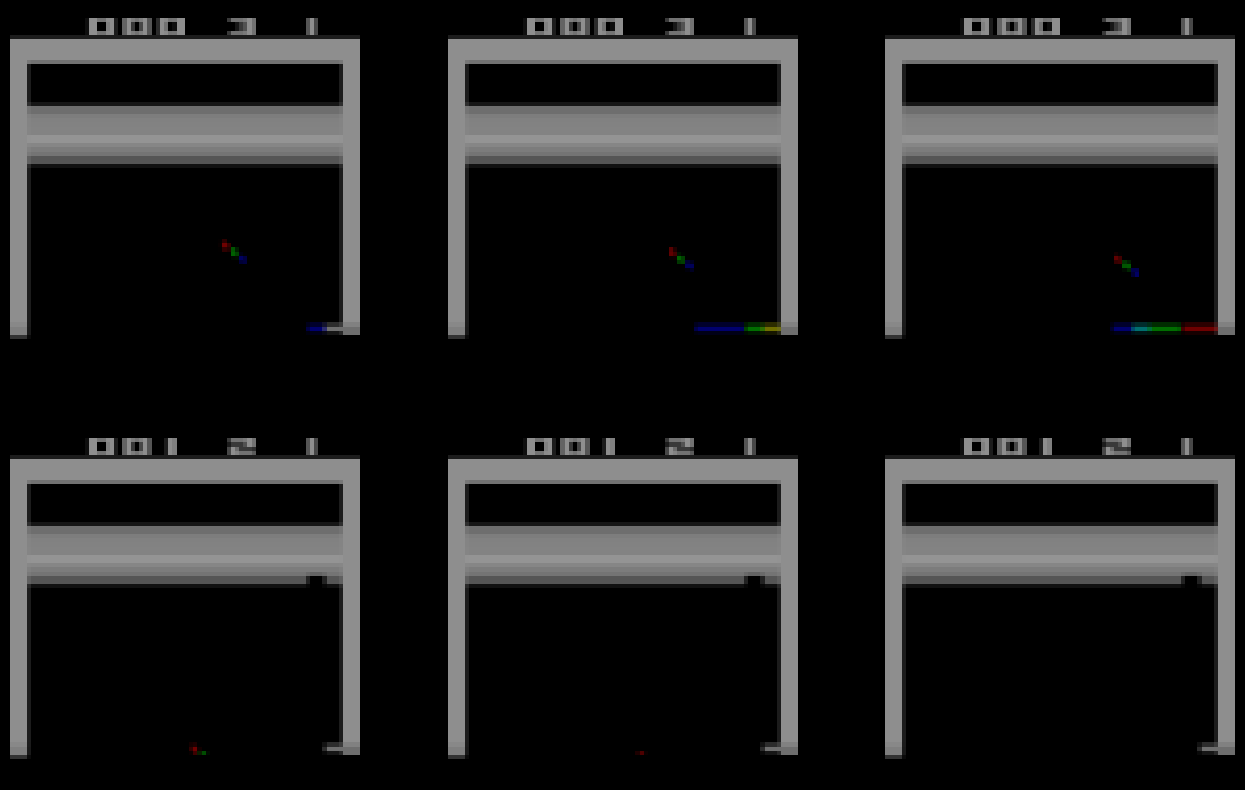

In [36]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(*list(trajectories.observation.shape[:2]), figsize=(16, 10))

for axs_tra, trajectory in zip(axs, trajectories.observation):
    for ax, obs in zip(axs_tra, trajectory):
        ax.imshow(obs[:, :, :-1])
        ax.axis("off")

In [37]:
from tf_agents.trajectories.trajectory import to_transition

time_steps, action_steps, next_time_steps = to_transition(trajectories)
time_steps.observation.shape

TensorShape([2, 2, 84, 84, 4])

In [38]:
trajectories.is_boundary()

<tf.Tensor: shape=(2, 3), dtype=bool, numpy=
array([[False, False, False],
       [False, False, False]])>

In [39]:
dataset = replay_buffer.as_dataset(
    sample_batch_size=64,
    num_steps=2,
    num_parallel_calls=3,
).prefetch(3)

Instructions for updating:
Use `tf.data.Dataset.counter(...)` instead.


Instructions for updating:
Use `tf.data.Dataset.counter(...)` instead.


## Creating the Training Loop

In [42]:
from tf_agents.utils import common

collect_driver.run = common.function(collect_driver.run)
agent.train = common.function(agent.train)


def train_agent(n_iterations: int) -> None:
    time_step = None
    policy_state = agent.collect_policy.get_initial_state(tf_env.batch_size)
    iterator = iter(dataset)
    for iteration in range(n_iterations):
        time_step, policy_state = collect_driver.run(time_step, policy_state)
        trajectories, buffer_info = next(iterator)
        train_loss = agent.train(trajectories)
        print(f"\r{iteration} loss:{train_loss.loss.numpy():.5f}", end="")
        if iteration % 1000 == 0:
            log_metrics(train_metrics)


train_agent(10_000_000)

2023-09-30 10:12:57.117302: W tensorflow/compiler/xla/service/gpu/llvm_gpu_backend/gpu_backend_lib.cc:274] libdevice is required by this HLO module but was not found at ./libdevice.10.bc
2023-09-30 10:12:57.117571: W tensorflow/core/framework/op_kernel.cc:1830] OP_REQUIRES failed at xla_ops.cc:362 : INTERNAL: libdevice not found at ./libdevice.10.bc
2023-09-30 10:12:57.117602: I tensorflow/core/common_runtime/executor.cc:1197] [/job:localhost/replica:0/task:0/device:GPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INTERNAL: libdevice not found at ./libdevice.10.bc
	 [[{{function_node __inference_train_1049358}}{{node StatefulPartitionedCall_8}}]]
2023-09-30 10:12:57.129731: W tensorflow/compiler/xla/service/gpu/llvm_gpu_backend/gpu_backend_lib.cc:274] libdevice is required by this HLO module but was not found at ./libdevice.10.bc
2023-09-30 10:12:57.130080: W tensorflow/core/framework/op_kernel.cc:1830] OP_REQUIRES failed at

InternalError: Graph execution error:

Detected at node 'StatefulPartitionedCall_8' defined at (most recent call last):
    File "/home/yuncong/mambaforge/envs/tf212/lib/python3.9/runpy.py", line 197, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "/home/yuncong/mambaforge/envs/tf212/lib/python3.9/runpy.py", line 87, in _run_code
      exec(code, run_globals)
    File "/home/yuncong/mambaforge/envs/tf212/lib/python3.9/site-packages/ipykernel_launcher.py", line 17, in <module>
      app.launch_new_instance()
    File "/home/yuncong/mambaforge/envs/tf212/lib/python3.9/site-packages/traitlets/config/application.py", line 1046, in launch_instance
      app.start()
    File "/home/yuncong/mambaforge/envs/tf212/lib/python3.9/site-packages/ipykernel/kernelapp.py", line 736, in start
      self.io_loop.start()
    File "/home/yuncong/mambaforge/envs/tf212/lib/python3.9/site-packages/tornado/platform/asyncio.py", line 195, in start
      self.asyncio_loop.run_f